In [1]:
pip install nltk pyspellchecker textdistance

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.2 MB 7.0 MB/s eta 0:00:01
   ---------- ----------------------------- 1.8/7.2 MB 5.0 MB/s eta 0:00:02
   -------------- ------------------------- 2.6/7.2 MB 4.6 MB/s eta 0:00:02
   ------------------ --------------------- 3.4/7.2 MB 4.4 MB/s eta 0:00:01
   ----------------------- ---------------- 4.2/7.2 MB 4.3 MB/s eta 0:00:01
   ------------------------ --------------- 4.5/7.2 MB 3.6 MB/s eta 0:00:01
   ------------------------------ --------- 5.5/7.2 MB 3.9 MB/s eta 0:00:01
   ---------------------------------- ----- 6.3/7.2 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 3.0 MB/s  0:00:02

   ------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from spellchecker import SpellChecker

import textdistance

from sklearn.metrics import confusion_matrix

In [5]:
df = pd.read_csv("unigram_freq.csv.zip")

df.head()

,word,count
0,the,23135851162
1,of,13151942776
2,and,12997637966
3,to,12136980858
4,a,9081174698


In [6]:
df.info()

df.shape

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333333 entries, 0 to 333332
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   word    333331 non-null  object
 1   count   333333 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 5.1+ MB


word     2
count    0
dtype: int64

In [7]:
# ## Dataset Inspection

# The dataset contains English words along with their frequency.

# Frequency represents how often a word appears in English language text.

# This frequency information will be used to build the autocomplete model.

In [8]:
df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

df["word"] = df["word"].str.lower()

df.head()

,word,count
0,the,23135851162
1,of,13151942776
2,and,12997637966
3,to,12136980858
4,a,9081174698


In [9]:
top20 = df.sort_values(
    by="count",
    ascending=False
).head(20)

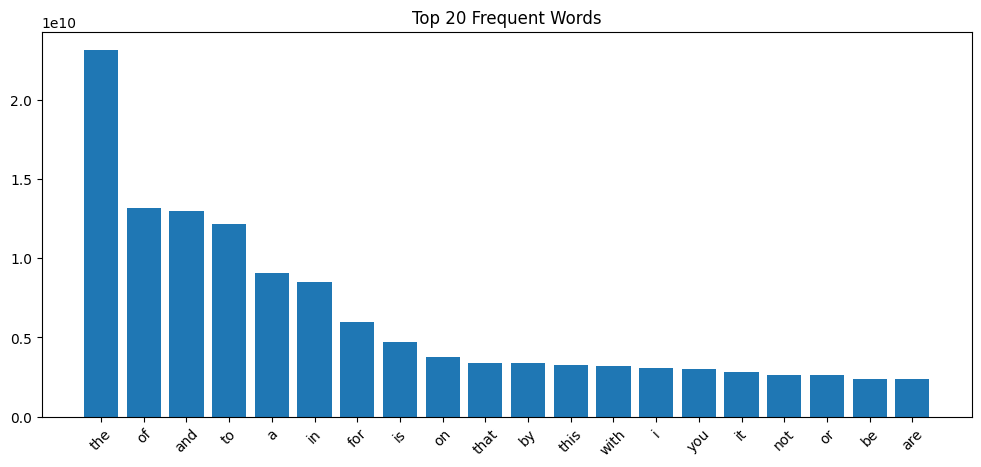

In [10]:
plt.figure(figsize=(12,5))

plt.bar(top20["word"], top20["count"])

plt.xticks(rotation=45)

plt.title("Top 20 Frequent Words")

plt.show()

In [11]:
# Observation

# Common English words dominate the corpus.

# These words are likely to appear frequently in autocomplete suggestions.

In [12]:
df["word"] = df["word"].str.lower()

df["word"] = df["word"].str.replace(
    r'[^a-z]',
    '',
    regex=True
)

df = df[df["word"]!=""]

In [13]:
# Preprocessing included

# • Lowercasing

# • Removing punctuation

# • Removing empty values

In [14]:
word_dict = dict(
    zip(
        df["word"],
        df["count"]
    )
)

In [15]:
def autocomplete(prefix):

    words = [
        word
        for word in word_dict
        if word.startswith(prefix)
    ]

    words = sorted(
        words,
        key=lambda x: word_dict[x],
        reverse=True
    )

    return words[:3]

In [16]:
prefixes = [
    "go",
    "pro",
    "auto",
    "comp",
    "inter",
    "data",
    "mach",
    "art",
    "learn",
    "prog"
]

for p in prefixes:

    print(p,"->",autocomplete(p))

go -> ['go', 'good', 'government']
pro -> ['products', 'product', 'program']
auto -> ['auto', 'automotive', 'automatically']
comp -> ['company', 'computer', 'compare']
inter -> ['international', 'internet', 'interest']
data -> ['data', 'database', 'databases']
mach -> ['machine', 'machines', 'machinery']
art -> ['art', 'article', 'articles']
learn -> ['learn', 'learning', 'learned']
prog -> ['program', 'programs', 'programme']


In [18]:
# Observation

# The autocomplete model successfully predicts the three most frequent words beginning with each prefix.

In [19]:
spell = SpellChecker()

In [20]:
misspelled = [

"enviroment",

"pyhton",

"recieve",

"adress",

"goverment",

"analitics",

"machne",

"lern",

"algoritm",

"autocorect",

"progamming",

"devloper",

"engeneer",

"apllication",

"moddel",

"langauge",

"frud",

"transction",

"datascince",

"statstics"

]

In [21]:
for word in misspelled:

    print(
        word,
        "->",
        spell.correction(word)
    )

enviroment -> environment
pyhton -> python
recieve -> receive
adress -> dress
goverment -> government
analitics -> analytic
machne -> machine
lern -> learn
algoritm -> algorithm
autocorect -> None
progamming -> programming
devloper -> developer
engeneer -> engineer
apllication -> application
moddel -> model
langauge -> language
frud -> fraud
transction -> transition
datascince -> None
statstics -> statistics


In [22]:
correct = [

"environment",

"python",

"receive",

"address",

"government",

"analytics",

"machine",

"learn",

"algorithm",

"autocorrect",

"programming",

"developer",

"engineer",

"application",

"model",

"language",

"fraud",

"transaction",

"datascience",

"statistics"

]

In [23]:
predicted = [
    spell.correction(word)
    for word in misspelled
]

accuracy = sum(
    p==c
    for p,c in zip(predicted,correct)
)/len(correct)

print("Autocorrect Accuracy:",accuracy)

Autocorrect Accuracy: 0.75


In [24]:
TP = sum(
    p==c
    for p,c in zip(predicted,correct)
)

FP = len(correct)-TP

FN = len(correct)-TP

precision = TP/(TP+FP)

recall = TP/(TP+FN)

print("Precision:",precision)

print("Recall:",recall)

Precision: 0.75
Recall: 0.75


In [25]:
comparison = pd.DataFrame({

"Approach":[

"Frequency Based",

"SpellChecker"

],

"Purpose":[

"Autocomplete",

"Autocorrect"

]

})

comparison

,Approach,Purpose
0,Frequency Based,Autocomplete
1,SpellChecker,Autocorrect


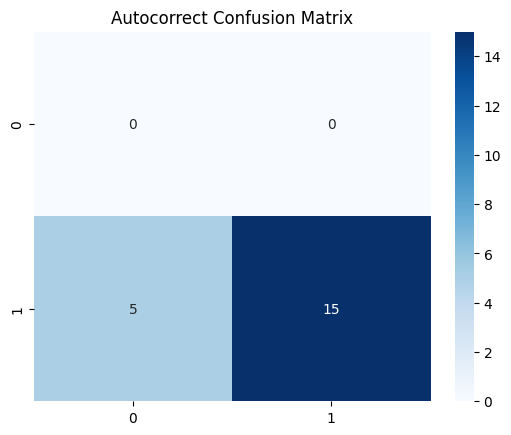

In [26]:
y_true = [1]*len(correct)

y_pred = [
    1 if p==c else 0
    for p,c in zip(predicted,correct)
]

cm = confusion_matrix(
    y_true,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Autocorrect Confusion Matrix")

plt.show()

In [27]:
# Discussion

# This implementation uses a simple frequency-based autocomplete model and an edit-distance-based spell checker.

# Unlike production systems such as Google Keyboard, it does not consider user history, context, grammar, deep learning, or personalized suggestions.

# Modern systems use transformer-based language models and neural networks to provide highly accurate and context-aware predictions.

In [28]:
# Conclusion

# • Built a frequency-based autocomplete system.

# • Implemented autocorrect using pyspellchecker.

# • Evaluated correction accuracy using precision and recall.

# • Compared autocomplete and autocorrect approaches.

# • Visualized the most frequent English words and correction performance.

# The project demonstrates fundamental NLP techniques used in intelligent text prediction systems.